# Laboratorio 3

## 1. Para los modelos generados en la sesión 3 tomar el 20% como datos para realizar el test y el 80% para realizar el entrenamiento y la validacion cruzada (por ejemplo 70% entrenamiento y 10% validacion cruzada). Construir una curva del score en función del parámetro gamma del clasificador que se esta empleando. ¿Cual presenta una mejor solución al problema?.

In [1]:
# imports
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import multivariate_normal
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.base import clone



In [2]:
def data(
    mu=[1, 1],
    mu1=[-2, 2],
    cov=[[1.0, 0.0], [0.0, 1.0]],
    cov1=[[1.0, -0.5], [-0.5, 1.0]],
):  # Caso mas visible
    rv = multivariate_normal(mu, cov)
    rv1 = multivariate_normal(mu1, cov1)
    return rv, rv1


rv, rv1 = data(
    mu=[1.2, 1.4],
    mu1=[1.4, -1.4],
    cov=[[1.0, -0.8], [-0.8, 1.0]],
    cov1=[[1.0, 0.8], [0.8, 1.0]],
)


def sample(N1=1000, N2=100, r=10):
    X_t = np.concatenate(
        [rv.rvs(N1, random_state=r), rv1.rvs(N2, random_state=r)]
    )  # Todos los datos en la misma distribución,
    y = np.concatenate([np.zeros(N1), np.ones(N2)])
    return X_t, y

In [3]:
X_t, y = sample()

X_dev, X_test, y_dev, y_test = train_test_split(
    X_t, y, test_size=0.2, random_state=42, stratify=y
)

In [4]:
def plot_decision_boundary(model, X, y, title):
    h = 0.05
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )

    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolors="k", s=20)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")


def evaluate_model(
    model,
    param_name,
    param_values,
    X_dev,
    y_dev,
    X_test,
    y_test,
    cv=8,
    scoring="accuracy",
    use_log_x=False,
    compare_class_weight=False,
):
    mean_scores = []
    std_scores = []

    # 1. Cross-validation for each parameter value
    for value in param_values:
        current_model = clone(model)
        current_model.set_params(**{param_name: value})

        scores = cross_val_score(
            current_model,
            X_dev,
            y_dev,
            cv=cv,
            scoring=scoring
        )

        mean_scores.append(scores.mean())
        std_scores.append(scores.std())

    mean_scores = np.array(mean_scores)
    std_scores = np.array(std_scores)

    # 2. Find best parameter
    best_index = np.argmax(mean_scores)
    best_value = param_values[best_index]
    best_score = mean_scores[best_index]

    print(f"Best {param_name}: {best_value}")
    print(f"Best CV score: {best_score}")

    # 3. Plot score curve
    plt.figure()
    if use_log_x:
        plt.semilogx(param_values, mean_scores, marker="o")
    else:
        plt.plot(param_values, mean_scores, marker="o")

    plt.fill_between(
        param_values,
        mean_scores - std_scores,
        mean_scores + std_scores,
        alpha=0.2,
    )
    plt.xlabel(param_name)
    plt.ylabel("Cross-validation score")
    plt.title(f"Score vs {param_name}")
    plt.grid(True)
    plt.show()

    # 4. Train best model
    best_model = clone(model)
    best_model.set_params(**{param_name: best_value})
    best_model.fit(X_dev, y_dev)

    # 5. Test performance
    y_pred = best_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    bal_acc = balanced_accuracy_score(y_test, y_pred)

    print("\nBest model on test set:")
    print("Accuracy:", acc)
    print("Balanced Accuracy:", bal_acc)

    # 6. Optional class_weight comparison
    if compare_class_weight and "class_weight" in model.get_params():
        model_unbalanced = clone(model)
        model_unbalanced.set_params(**{param_name: best_value, "class_weight": None})
        model_unbalanced.fit(X_dev, y_dev)

        model_balanced = clone(model)
        model_balanced.set_params(**{param_name: best_value, "class_weight": "balanced"})
        model_balanced.fit(X_dev, y_dev)

        plt.figure(figsize=(12, 5))

        plt.subplot(1, 2, 1)
        plot_decision_boundary(model_unbalanced, X_dev, y_dev, "Without class_weight")

        plt.subplot(1, 2, 2)
        plot_decision_boundary(model_balanced, X_dev, y_dev, "With class_weight='balanced'")

        plt.tight_layout()
        plt.show()

        for name, current_model in [
            ("Unbalanced", model_unbalanced),
            ("Balanced", model_balanced),
        ]:
            y_pred = current_model.predict(X_test)
            print(f"\n{name}:")
            print("Accuracy:", accuracy_score(y_test, y_pred))
            print("Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred))

    return best_model, best_value, best_score

Best gamma: 5.455594781168514
Best CV score: 0.9647727272727273


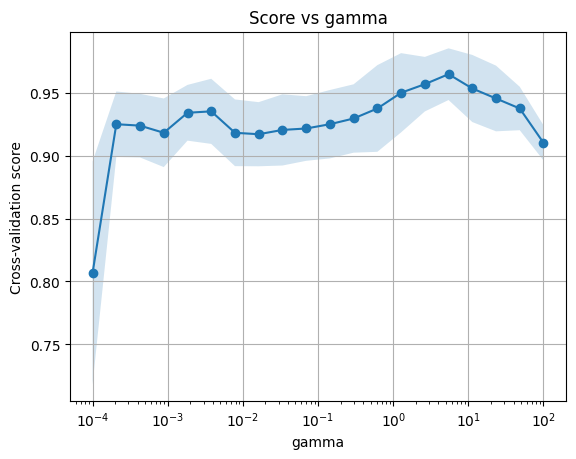


Best model on test set:
Accuracy: 0.95
Balanced Accuracy: 0.9275


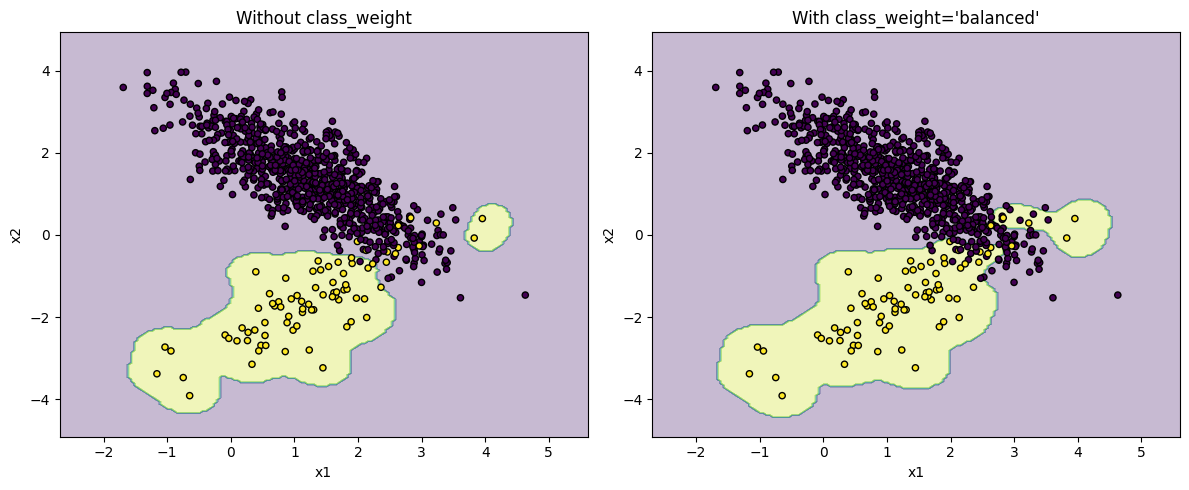


Unbalanced:
Accuracy: 0.9772727272727273
Balanced Accuracy: 0.8975

Balanced:
Accuracy: 0.95
Balanced Accuracy: 0.9275


In [5]:
from sklearn.svm import SVC

gammas = np.logspace(-4, 2, 20)

best_model, best_gamma, best_score = evaluate_model(
    model=SVC(kernel="rbf", class_weight="balanced"),
    param_name="gamma",
    param_values=gammas,
    X_dev=X_dev,
    y_dev=y_dev,
    X_test=X_test,
    y_test=y_test,
    cv=8,
    scoring="accuracy",
    use_log_x=True,
    compare_class_weight=True,
)

Best max_depth: 9
Best CV score: 0.9693181818181819


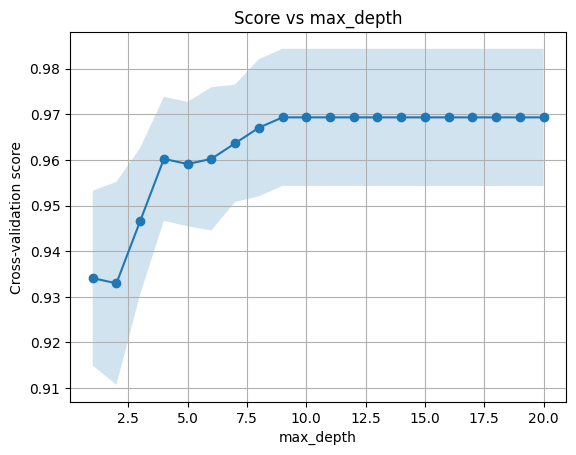


Best model on test set:
Accuracy: 0.9636363636363636
Balanced Accuracy: 0.9125


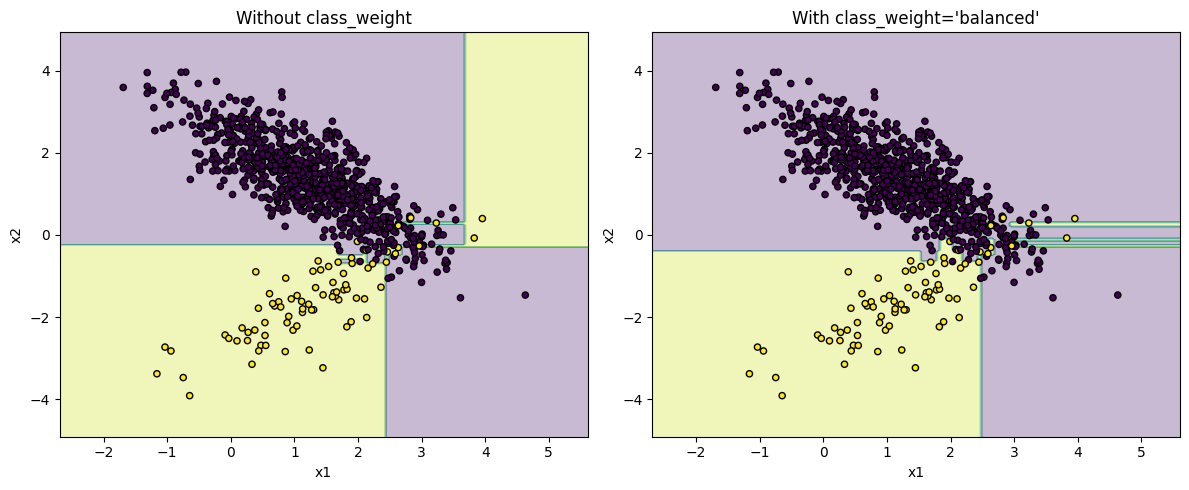


Unbalanced:
Accuracy: 0.9727272727272728
Balanced Accuracy: 0.94

Balanced:
Accuracy: 0.9636363636363636
Balanced Accuracy: 0.9125


In [6]:
from sklearn.tree import DecisionTreeClassifier

depths = np.arange(1, 21)

best_tree, best_depth, best_tree_score = evaluate_model(
    model=DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    param_name="max_depth",
    param_values=depths,
    X_dev=X_dev,
    y_dev=y_dev,
    X_test=X_test,
    y_test=y_test,
    cv=8,
    scoring="accuracy",
    use_log_x=False,
    compare_class_weight=True,
)

Best n_estimators: 20
Best CV score: 0.9806818181818182


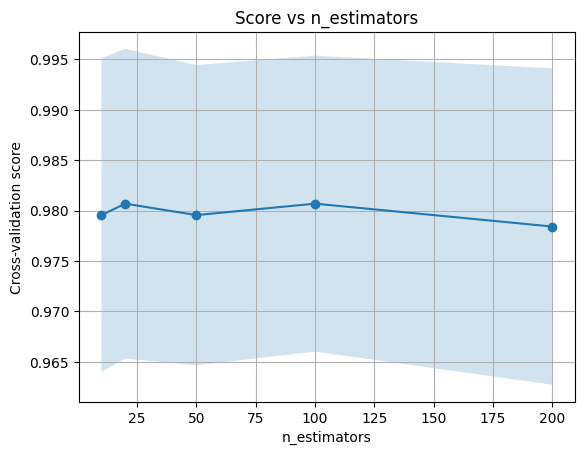


Best model on test set:
Accuracy: 0.9727272727272728
Balanced Accuracy: 0.9175


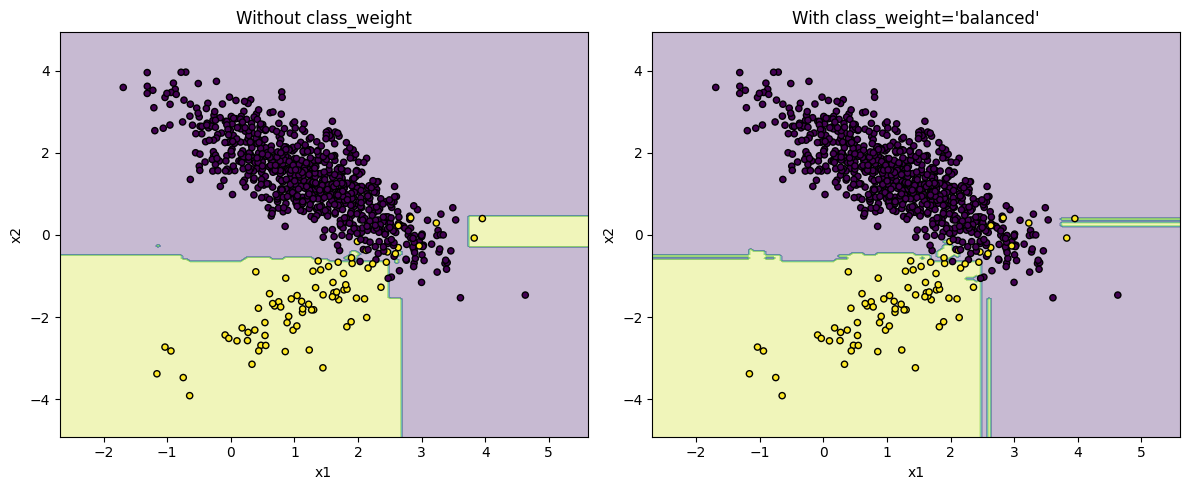


Unbalanced:
Accuracy: 0.9818181818181818
Balanced Accuracy: 0.9225

Balanced:
Accuracy: 0.9727272727272728
Balanced Accuracy: 0.9175


In [7]:
from sklearn.ensemble import RandomForestClassifier

n_trees = [10, 20, 50, 100, 200]

best_rf, best_n, best_rf_score = evaluate_model(
    model=RandomForestClassifier(random_state=42, class_weight="balanced"),
    param_name="n_estimators",
    param_values=n_trees,
    X_dev=X_dev,
    y_dev=y_dev,
    X_test=X_test,
    y_test=y_test,
    cv=8,
    scoring="accuracy",
    use_log_x=False,
    compare_class_weight=True,
)

In [8]:
def show_summary(name, best_value, best_score):
    print(f"{name}:")
    print(f"  Best parameter value: {best_value}")
    print(f"  Best CV score: {best_score}")

In [9]:
show_summary("SVC", best_gamma, best_score)
show_summary("Decision Tree", best_depth, best_tree_score)
show_summary("Random Forest", best_n, best_rf_score)

SVC:
  Best parameter value: 5.455594781168514
  Best CV score: 0.9647727272727273
Decision Tree:
  Best parameter value: 9
  Best CV score: 0.9693181818181819
Random Forest:
  Best parameter value: 20
  Best CV score: 0.9806818181818182


Se evaluaron tres modelos: SVC, Decision Tree y Random Forest, utilizando validación cruzada para seleccionar el mejor hiperparámetro en cada caso.

En términos de validación cruzada, el modelo Random Forest obtuvo el mejor desempeño, con un score de 0.9807 para n_estimators = 20, seguido por Decision Tree (0.9693) y SVC (0.9648).

Al evaluar en el conjunto de prueba, Random Forest también presentó la mayor exactitud (accuracy = 0.9818), lo que indica una excelente capacidad de generalización. Sin embargo, al considerar la métrica de balanced accuracy, que es más adecuada para datos desbalanceados, el mejor resultado lo obtuvo el Decision Tree sin ponderación de clases (balanced accuracy = 0.94).

En el caso de SVC, el uso de class_weight="balanced" fue necesario para mejorar el desempeño sobre la clase minoritaria, mientras que en Decision Tree y Random Forest no se observaron mejoras al aplicar ponderación de clases.

En conclusión, si el objetivo es maximizar la exactitud global, el mejor modelo es Random Forest. No obstante, si se busca un mejor equilibrio en la clasificación de ambas clases, el Decision Tree sin class weights presenta la mejor solución.

## 2. Construir las curvas de aprendizaje estadístico para el modelo descrito, comprobar que la solución es similar a la que se obtiene a través de sklearn. GridSearch: https://scikit-learn.org/stable/modules/grid_search.html

In [10]:
from sklearn.model_selection import learning_curve


def plot_learning_curve(model, X, y, title, cv=8, scoring="accuracy"):
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 10),
        shuffle=True,
        random_state=42,
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)

    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure()
    plt.plot(train_sizes, train_mean, "o-", label="Training score")
    plt.plot(train_sizes, val_mean, "o-", label="Validation score")

    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2,
    )

    plt.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.2,
    )

    plt.xlabel("Training set size")
    plt.ylabel(scoring)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

### SVC

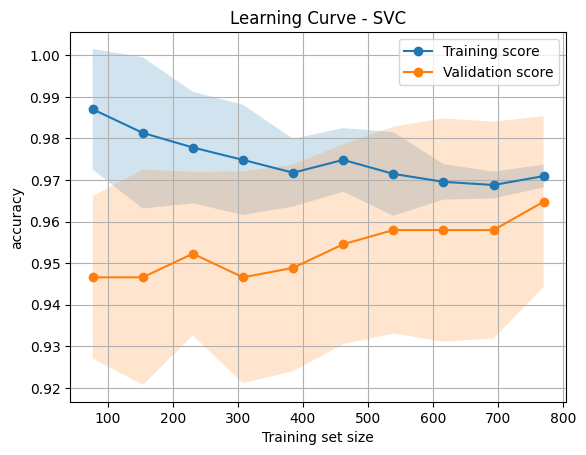

In [11]:
best_svc = SVC(kernel="rbf", gamma=5.455594781168514, class_weight="balanced")

plot_learning_curve(
    best_svc,
    X_dev,
    y_dev,
    "Learning Curve - SVC"
)

### Decision Tree

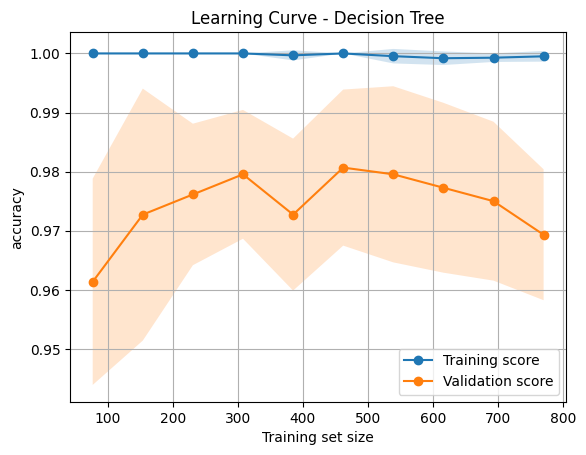

In [12]:
best_tree = DecisionTreeClassifier(max_depth=9)

plot_learning_curve(
    best_tree,
    X_dev,
    y_dev,
    "Learning Curve - Decision Tree"
)

### Random Forest

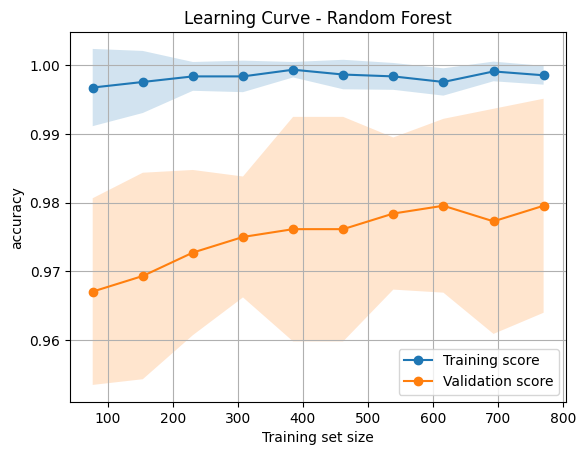

In [13]:
best_rf = RandomForestClassifier(n_estimators=20)

plot_learning_curve(
    best_rf,
    X_dev,
    y_dev,
    "Learning Curve - Random Forest"
)

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid_svc = {
    "gamma": np.logspace(-4, 2, 20)
}

grid_svc = GridSearchCV(
    SVC(kernel="rbf", class_weight="balanced"),
    param_grid_svc,
    cv=8,
    scoring="accuracy"
)

grid_svc.fit(X_dev, y_dev)

print("Best gamma (GridSearch):", grid_svc.best_params_)
print("Best CV score:", grid_svc.best_score_)

Best gamma (GridSearch): {'gamma': np.float64(5.455594781168514)}
Best CV score: 0.9647727272727273


In [15]:
param_grid_tree = {
    "max_depth": np.arange(1, 21)
}

grid_tree = GridSearchCV(
    DecisionTreeClassifier(),
    param_grid_tree,
    cv=8,
    scoring="accuracy"
)

grid_tree.fit(X_dev, y_dev)

print("Best max_depth:", grid_tree.best_params_)
print("Best CV score:", grid_tree.best_score_)

Best max_depth: {'max_depth': np.int64(2)}
Best CV score: 0.9806818181818182


In [16]:
param_grid_rf = {
    "n_estimators": [10, 20, 50, 100, 200]
}

grid_rf = GridSearchCV(
    RandomForestClassifier(),
    param_grid_rf,
    cv=8,
    scoring="accuracy"
)

grid_rf.fit(X_dev, y_dev)

print("Best n_estimators:", grid_rf.best_params_)
print("Best CV score:", grid_rf.best_score_)

Best n_estimators: {'n_estimators': 100}
Best CV score: 0.9806818181818182


### Learning curve para Decision Tree con GridSearch

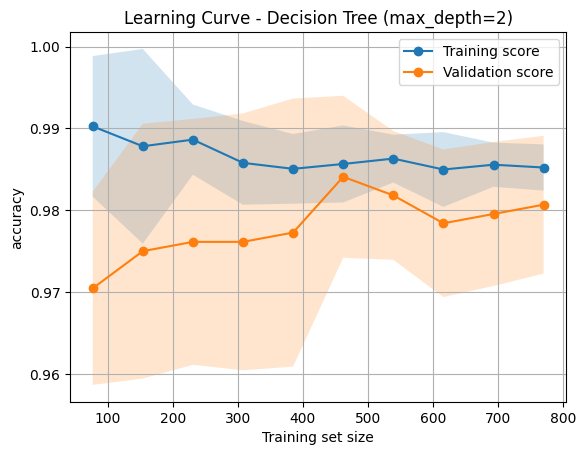

In [17]:
best_tree = DecisionTreeClassifier(max_depth=2)

plot_learning_curve(
    best_tree,
    X_dev,
    y_dev,
    "Learning Curve - Decision Tree (max_depth=2)"
)

El modelo SVC muestra una diferencia pequna entre el training and validation scores, que dcrese a medida que el conjunto de test incrementa, lo cual es una buena senal. Esto indica que el modelo tiene buena generalizacion.

El modelo Decision Tree presenta un score muy cercano a 1 para todos los tamanos de test y una diferencia considerable con el score de validacion, lo que implica que el modelo esta haciendo overfitting. El modelo memoriza los datos pero no generaliza bien.

El modelo Random Forest alcanza altos scores de entrenamiento y validacion y el gap entre ellos decrese a medida que el tamano de los datos de entrenamiento crece, lo que indica que se reduce el overfitting y el modelo hace buena generalizacion.

La busqueda de hiperparametros con GridSearch dio resultados similares a los encontrados manualmente para SVC y Random Forest pero no para Decision Tree.

La nueva curva de aprendizaje para Decision Tree con el hiperparametro encontrado con GridSearch muestra un comportamiento mucho mejor del modelo. La diferencia entre el training score y validation score decrece a medida que el tamano del conjunto de entrenamiento incrementa. Esto nos dice que con este hiperparametro, el modelo es capaz de generalizar mucho mejor y se reduce el overfitting.

Como resultado, Random Forest tiene un mejor rendimiento.

## 3. Tomando el mejor modelo para los datos ahora van crear nuevos datasets donde el modelo se espera no va a ser optimo sino que presenta overfitting y underfitting. Elegir, los párametros adecuados para los centros de medias y las matrices de covarianzas y mostrar graficamente un ejemplo de overfitting y uno de underfitting con el modelo óptimo anterior. Analizar los resultados.

In [18]:
def sample_from_distributions(rv0, rv1, N0=1000, N1=100, r=10):
    X = np.concatenate([
        rv0.rvs(N0, random_state=r),
        rv1.rvs(N1, random_state=r)
    ])
    y = np.concatenate([
        np.zeros(N0),
        np.ones(N1)
    ])
    return X, y

In [19]:
def evaluate_dataset_with_best_model(
    rv0,
    rv1,
    N0,
    N1,
    title,
    model,
    random_state=42,
    cv=8,
    scoring="accuracy",
):
    X, y = sample_from_distributions(rv0, rv1, N0=N0, N1=N1, r=random_state)

    X_dev, X_test, y_dev, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    model.fit(X_dev, y_dev)

    y_pred_dev = model.predict(X_dev)
    y_pred_test = model.predict(X_test)

    print(f"\n{title}")
    print("Train Accuracy:", accuracy_score(y_dev, y_pred_dev))
    print("Test Accuracy:", accuracy_score(y_test, y_pred_test))
    print("Train Balanced Accuracy:", balanced_accuracy_score(y_dev, y_pred_dev))
    print("Test Balanced Accuracy:", balanced_accuracy_score(y_test, y_pred_test))

    # Decision boundary
    plt.figure(figsize=(6, 5))
    plot_decision_boundary(model, X_dev, y_dev, f"{title} - Decision Boundary")
    plt.tight_layout()
    plt.show()

    # Learning curve
    train_sizes, train_scores, val_scores = learning_curve(
        model,
        X_dev,
        y_dev,
        cv=cv,
        scoring=scoring,
        train_sizes=np.linspace(0.1, 1.0, 10),
        shuffle=True,
        random_state=42,
    )

    train_mean = train_scores.mean(axis=1)
    train_std = train_scores.std(axis=1)

    val_mean = val_scores.mean(axis=1)
    val_std = val_scores.std(axis=1)

    plt.figure(figsize=(7, 5))
    plt.plot(train_sizes, train_mean, "o-", label="Training score")
    plt.plot(train_sizes, val_mean, "o-", label="Validation score")

    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2,
    )

    plt.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.2,
    )

    plt.xlabel("Training set size")
    plt.ylabel(scoring)
    plt.title(f"{title} - Learning Curve")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return {
        "X_dev": X_dev,
        "X_test": X_test,
        "y_dev": y_dev,
        "y_test": y_test,
        "train_accuracy": accuracy_score(y_dev, y_pred_dev),
        "test_accuracy": accuracy_score(y_test, y_pred_test),
        "train_balanced_accuracy": balanced_accuracy_score(y_dev, y_pred_dev),
        "test_balanced_accuracy": balanced_accuracy_score(y_test, y_pred_test),
        "train_sizes": train_sizes,
        "train_scores_mean": train_mean,
        "train_scores_std": train_std,
        "val_scores_mean": val_mean,
        "val_scores_std": val_std,
    }

### Underfitting


Underfitting example - Random Forest
Train Accuracy: 0.9886363636363636
Test Accuracy: 0.9
Train Balanced Accuracy: 0.9375
Test Balanced Accuracy: 0.5175


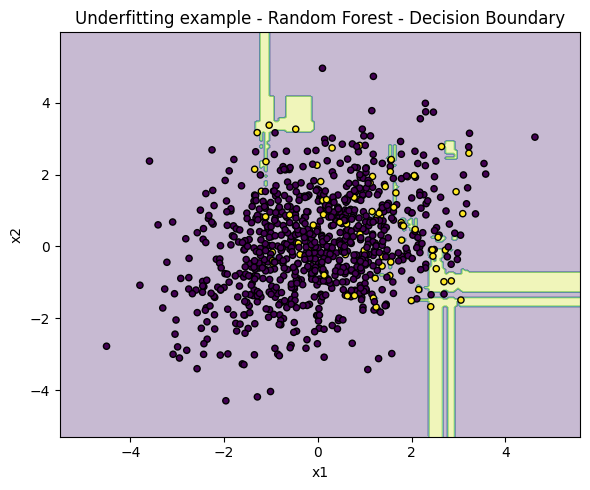

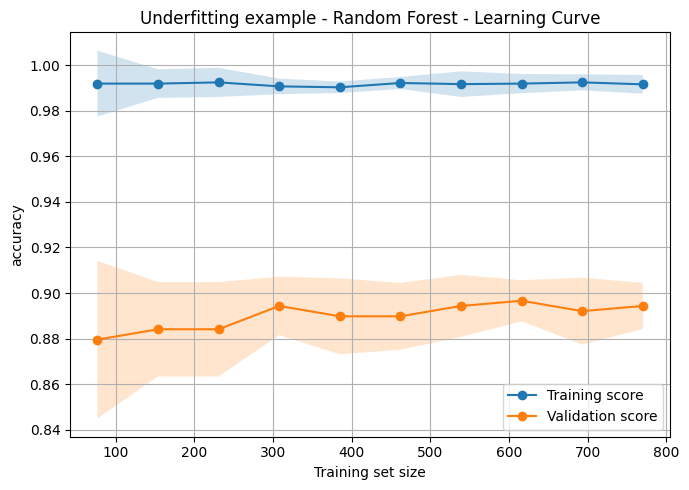

In [20]:
rv_u0, rv_u1 = data(
    mu=[0.0, 0.0],
    mu1=[0.8, 0.8],
    cov=[[2.0, 0.8], [0.8, 2.0]],
    cov1=[[2.0, -0.8], [-0.8, 2.0]],
)

underfit_results = evaluate_dataset_with_best_model(
    rv0=rv_u0,
    rv1=rv_u1,
    N0=1000,
    N1=100,
    title="Underfitting example - Random Forest",
    model=RandomForestClassifier(n_estimators=20, random_state=42),
)


Overfitting example - Random Forest
Train Accuracy: 1.0
Test Accuracy: 0.5
Train Balanced Accuracy: 1.0
Test Balanced Accuracy: 0.375


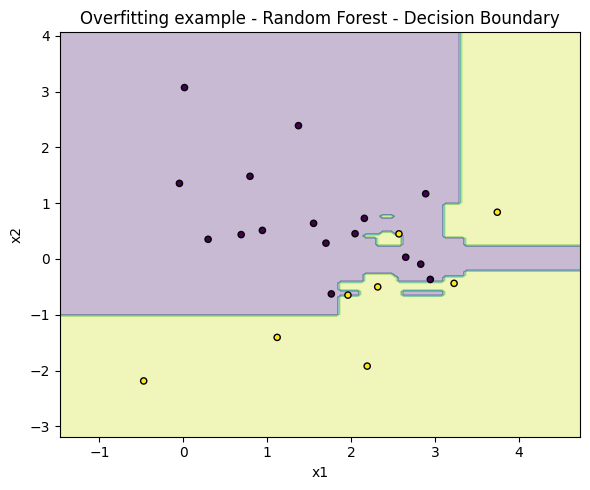

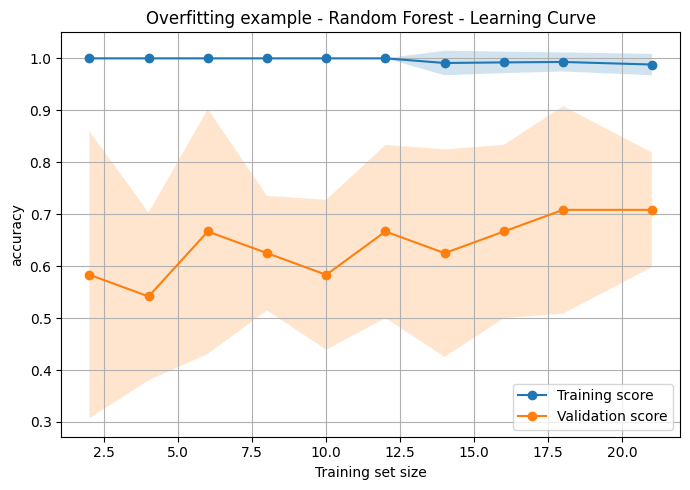

In [26]:
rv_o0, rv_o1 = data(
    mu=[1.4, 1.0],
    mu1=[1.6, -0.8],
    cov=[[1.4, -1.0], [-1.0, 1.4]],
    cov1=[[1.4, 1.0], [1.0, 1.4]],
)

overfit_results = evaluate_dataset_with_best_model(
    rv0=rv_o0,
    rv1=rv_o1,
    N0=20,
    N1=10,
    title="Overfitting example - Random Forest",
    model=RandomForestClassifier(n_estimators=20, random_state=42),
)

Para el ejemplo de underfitting, las medias de los datos fueron colocadas cerca y las matrices de covarianza son amplias, causando overlap de los datos, lo que dificulta la separacion y creacion de una frontera para clasificar los datos. En ste caso, aunque el training accuracy se mantiene alto, el balanced accuaracy cae a un valor de 50% con lo cual podemos decirt que el modelo basicamente esta adivinando y es incapaz de distinguir los datos.

Para el ejemplo de overfitting, se uso un dataset mas pequeno, y matrices de covarianza mas estructuradas. En este caso el modelo es capaz de clasificar perfectamente los datos de entrenamiento pero falla al generalizar nuevos datos. esto se debe a la peque;a cantidad de datos disponibles.